In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
csv_map = {
    "random":      "./data_size/issue_all/random_sampling_merged.csv",
    "stratified":  "./data_size/issue_all/stratified_random_sampling_merged.csv",
    "systematic":  "./data_size/issue_all/systematic_sampling_merged.csv",
}

In [4]:
def plot_group_band_valid_rate_vs_sample_ratio(
    group_map,
    N_POP=500_000,
    title="Random sampling: bands of fraction within tolerance vs sample size ratio",
    figsize=(3.4, 2.2),
    ymin=0.0,
    ymax=1.05,
    xmax=0.1,
    file_name=None,
    xscale="linear",      
    savgol_window=31,     
    savgol_poly=3,   
):

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    color_cycle = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive",
        "tab:cyan",
    ]

    def savgol_1d(y, window_length, polyorder):
        y = np.asarray(y, float)
        n = len(y)
        if n < 5:
            return y

        if window_length is None:
            window_length = max(5, n // 10)
        if window_length % 2 == 0:
            window_length += 1
        if window_length > n:
            window_length = n if n % 2 == 1 else n - 1
        if window_length <= polyorder:
            window_length = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3

        try:
            return savgol_filter(y, window_length=window_length, polyorder=polyorder)
        except Exception:
            return y

    all_ratios_global = []

    for g_idx, (group_label, csv_list) in enumerate(group_map.items()):
        dfs_smooth = []

        for i, path in enumerate(csv_list):
            df = pd.read_csv(path)
            if "n" not in df.columns or "valid_rate" not in df.columns:
                raise ValueError(f"CSV {path} 必须包含列 'n' 和 'valid_rate'")

            df = df.sort_values("n").copy()
            n_vals = df["n"].to_numpy(dtype=float)
            v_vals = df["valid_rate"].to_numpy(dtype=float)

            v_smooth = savgol_1d(v_vals, window_length=savgol_window, polyorder=savgol_poly)

            dfs_smooth.append(
                pd.DataFrame({
                    "n": n_vals,
                    f"v{i}": v_smooth,     # 每条曲线一个列名 v0、v1、...
                })
            )

        # 2) 按 n 做 outer merge，把这一组的平滑曲线合在一起
        merged = dfs_smooth[0]
        for i in range(1, len(dfs_smooth)):
            merged = merged.merge(dfs_smooth[i], on="n", how="outer")

        merged = merged.sort_values("n")
        n_col = merged["n"].to_numpy()
        ratio = n_col / float(N_POP)
        all_ratios_global.append(ratio)

        vals = merged.filter(like="v").to_numpy(dtype=float)

        v_min = np.nanmin(vals, axis=1)
        v_max = np.nanmax(vals, axis=1)
        v_mean = np.nanmean(vals, axis=1)

        color = color_cycle[g_idx % len(color_cycle)]

        ax.fill_between(
            ratio,
            v_min,
            v_max,
            color=color,
            alpha=0.18,
            linewidth=0,
        )

        ax.plot(
            ratio,
            v_mean,
            color=color,
            linewidth=0.8,
            label=group_label,
        )

    all_ratios_global = np.concatenate(all_ratios_global)
    positive_ratios = all_ratios_global[all_ratios_global > 0]

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.6, alpha=0.7)
    
    label_fontsize = 6

    ax.set_xlabel(
        "Sample size as a fraction of full website population",
        fontsize=label_fontsize,
    )
    ax.set_ylabel("Fraction of runs within tolerance", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=5)

    ax.set_ylim(ymin, ymax)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, linestyle="--", alpha=0.3)

    if xscale == "log":
        ax.set_xscale("log")

        if positive_ratios.size > 0:
            xmin = positive_ratios.min()
        else:
            xmin = xmax / 100.0
        xmin = max(xmin, 1e-6)
        ax.set_xlim(xmin, xmax)

        xticks = np.array([
            0.001, 0.002, 0.005,
            0.01, 0.02, 0.05,
            0.1, 0.2, 0.5,
        ])
        xticks = xticks[(xticks >= xmin) & (xticks <= xmax)]
        if xticks.size > 0:
            ax.set_xticks(xticks)

        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{x*100:.2f}%")
        )
    else:
        ax.set_xlim(0, xmax)
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{x:.1%}")
        )
    
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
        ax.tick_params(width=0.4)
    

    ax.legend(frameon=True, fontsize=5)
    plt.tight_layout()
    plt.show()

    if file_name is not None:
        fig.savefig(file_name, dpi=300, bbox_inches="tight", pad_inches=0)

    plt.close(fig)

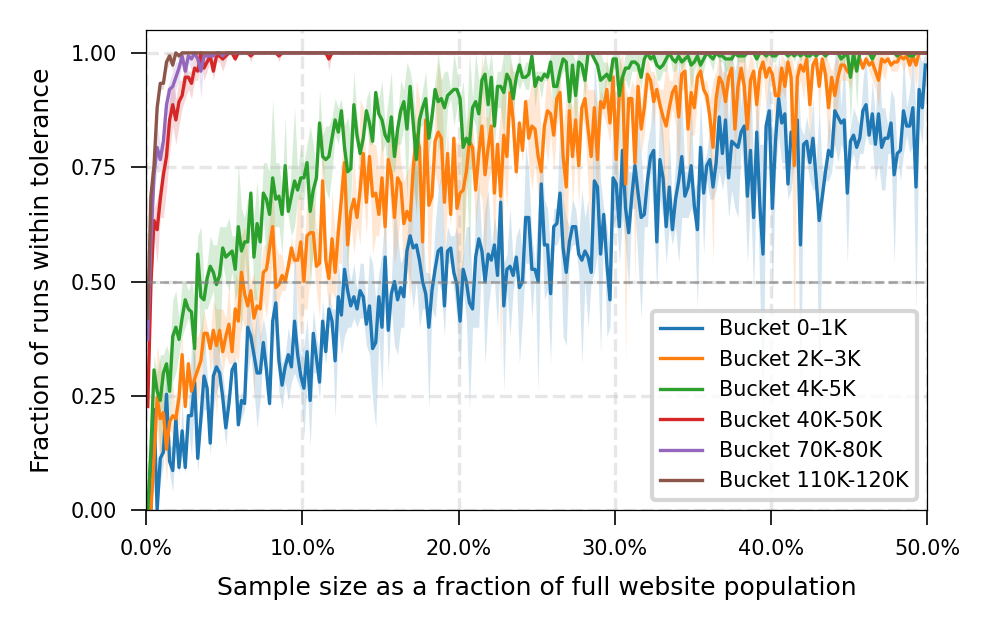

In [6]:
group_map = {
    "Bucket 0–1K": [
        "./sample_size/issue_cxss/stratified_random_sampling_merged.csv",
        "./sample_size/issue_cxss/random_sampling_merged.csv",
        "./sample_size/issue_cxss/systematic_sampling_merged.csv",
    ],
    "Bucket 2K–3K": [
        "./sample_size/issue_type/stratified_random_sampling_merged.csv",
        "./sample_size/issue_type/random_sampling_merged.csv",
        "./sample_size/issue_type/systematic_sampling_merged.csv",
    ],
    "Bucket 4K-5K": [
        "./sample_size/issue_ssl/stratified_random_sampling_merged.csv",
        "./sample_size/issue_ssl/random_sampling_merged.csv",
        "./sample_size/issue_ssl/systematic_sampling_merged.csv",
    ],
    "Bucket 40K-50K": [
        "./sample_size/issue_click/stratified_random_sampling_merged.csv",
        "./sample_size/issue_click/random_sampling_merged.csv",
        "./sample_size/issue_click/systematic_sampling_merged.csv",
    ],
    "Bucket 70K-80K": [
        "./sample_size/issue_hsts/stratified_random_sampling_merged.csv",
        "./sample_size/issue_hsts/random_sampling_merged.csv",
        "./sample_size/issue_hsts/systematic_sampling_merged.csv",
    ],
    "Bucket 110K-120K": [
        "./sample_size/issue_cookie/stratified_random_sampling_merged.csv",
        "./sample_size/issue_cookie/random_sampling_merged.csv",
        "./sample_size/issue_cookie/systematic_sampling_merged.csv",
    ],
}

plot_group_band_valid_rate_vs_sample_ratio(
    group_map=group_map,
    N_POP=500_000,
    xmax=0.5,
    file_name="./sensititivity.pdf",
    savgol_window=0, 
    savgol_poly=3,
)